# Fixation Regional PC CCA and Connectivity-Constrained mRNNs

This notebook builds 42-PC regional fixation trajectories, checks pairwise CCA across regions, and compares three mRNN recurrent-connectivity variants:

- `full`: all region-to-region recurrent blocks.
- `within_region`: only each region's internal recurrent block.
- `cross_region_with_self_diagonal`: cross-region recurrent blocks plus diagonal self dynamics inside each region.

The model settings here use 50 hidden units per region, `tanh` activation, and unconstrained recurrent/input weights.

## 1. Setup

In [1]:
from pathlib import Path
from dataclasses import replace
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from dal_monte_2022_analysis.ephys.modeling import (
    backproject_replay_outputs_to_firing_rates,
    compute_pairwise_regional_pc_cca,
    load_fixation_mrnn_config,
    make_targets,
    pc_reconstructed_firing_rate_accuracy,
    plot_pairwise_cca_variance,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    settings_from_config,
    train_fixation_mrnn_scratch,
    variance_comparison,
)
from dal_monte_2022_analysis.ephys.plotting.fixation_mrnn import (
    plot_fixation_mrnn_activation_pc_timeseries,
)


def display_figure(fig, *, dpi=150):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))


## 2. Fixed Model and Target Settings

In [2]:
cfg = load_fixation_mrnn_config(repo_root / "configs" / "ephys_fixation_mrnn.yaml")
base_settings = settings_from_config(cfg)
base_settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
base_settings.device = "auto"
base_settings.target_mode = "region_pcs"
base_settings.pca_n_components = 42
base_settings.temporal_basis_count = 0
base_settings.hidden_units = 50
base_settings.activation = "tanh"
base_settings.rec_constrained = False
base_settings.inp_constrained = False
base_settings.spectral_radius = 1.1
base_settings.epochs = 50_000
base_settings.lr = 3e-4
base_settings.loss_fn = "mse"
base_settings.temporal_derivative_loss_scale = 1.0
base_settings.temporal_curvature_loss_scale = 0.5
base_settings.correlation_loss_scale = 0.1
base_settings.variance_loss_scale = 0.1
base_settings.fr_reconstruction_loss_scale = 1.0
base_settings.fr_temporal_derivative_loss_scale = 0.5
base_settings.fr_temporal_curvature_loss_scale = 0.25
base_settings.l1_weight_scale = 0.0
base_settings.l1_rate_scale = 0.0
base_settings.l2_weight_scale = 0.0
base_settings.l2_rate_scale = 0.0
base_settings.gradient_clip_norm = 1.0
base_settings.initialization_mode = "single"
base_settings.overwrite_seed_plan = False
base_settings

FixationMRNNRunSettings(dataset_cfg_path='/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/configs/dataset.yaml', input_subdir='ephys/psth/fixation_psth_averages', dataframe_filename='fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl', timeline_filename='fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl', output_subdir='ephys/modeling/fixation_mrnn', region_order=('ofc', 'bla', 'dmpfc', 'accg'), condition_order=('face_interactive', 'face_non_interactive', 'object'), target_mode='region_pcs', normalize_targets=True, normalization_stabilizer=5.0, pca_variance_threshold=0.95, pca_n_components=42, temporal_basis_count=0, hidden_units=50, activation='tanh', spectral_radius=1.1, rec_constrained=False, inp_constrained=False, recurrent_connectivity='full', batch_first=True, inp_noise=0.0, act_noise=0.0, epochs=50000, lr=0.0003, loss_fn='mse', temporal_derivative_loss_scale=1.0, temporal_curvature_loss_scale=0.5, correlation_loss_scale=0.1, varian

## 3. Build 42-PC Regional Targets

In [3]:
targets = make_targets(base_settings)
rows = []
for region in targets.region_order:
    pca = targets.pca_by_region[region]
    rows.append({
        "region": region,
        "raw_shape": targets.raw_by_region[region].shape,
        "pc_shape": targets.pcs_by_region[region].shape,
        "n_source_neurons": len(pca.source_features),
        "saved_pc_components": targets.pcs_by_region[region].shape[-1],
        "pcs_required_by_variance_rule": pca.n_components_required,
        "normalization_scale": targets.normalization_scale,
    })
display(pd.DataFrame(rows))

,region,raw_shape,pc_shape,n_source_neurons,saved_pc_components,pcs_required_by_variance_rule,normalization_scale
0,ofc,"(3, 100, 241)","(3, 100, 42)",241,42,38,24.363274
1,bla,"(3, 100, 537)","(3, 100, 42)",537,42,42,24.363274
2,dmpfc,"(3, 100, 187)","(3, 100, 42)",187,42,33,24.363274
3,accg,"(3, 100, 236)","(3, 100, 42)",236,42,40,24.363274


## 4. Pairwise Regional CCA

,region_a,region_b,cca_dimension,canonical_correlation,region_a_variance_explained,region_b_variance_explained,mean_variance_explained,region_a_cumulative_variance_explained,region_b_cumulative_variance_explained,mean_cumulative_variance_explained
0,ofc,bla,1,0.999819,0.285350,0.275681,0.280516,0.285350,0.275681,0.280516
1,ofc,bla,2,0.999527,0.167460,0.173876,0.170668,0.452811,0.449557,0.451184
2,ofc,bla,3,0.998971,0.049034,0.029504,0.039269,0.501845,0.479061,0.490453
3,ofc,bla,4,0.998421,0.024455,0.028835,0.026645,0.526300,0.507897,0.517098
4,ofc,bla,5,0.998216,0.032083,0.019843,0.025963,0.558383,0.527740,0.543061
5,ofc,bla,6,0.997673,0.020491,0.017074,0.018782,0.578874,0.544814,0.561844
6,ofc,bla,7,0.997563,0.025367,0.022299,0.023833,0.604241,0.567113,0.585677
7,ofc,bla,8,0.996484,0.016726,0.016250,0.016488,0.620967,0.583362,0.602164
8,ofc,bla,9,0.995962,0.013904,0.018611,0.016257,0.634870,0.601974,0.618422
9,ofc,bla,10,0.995155,0.013549,0.012633,0.013091,0.648419,0.614607,0.631513


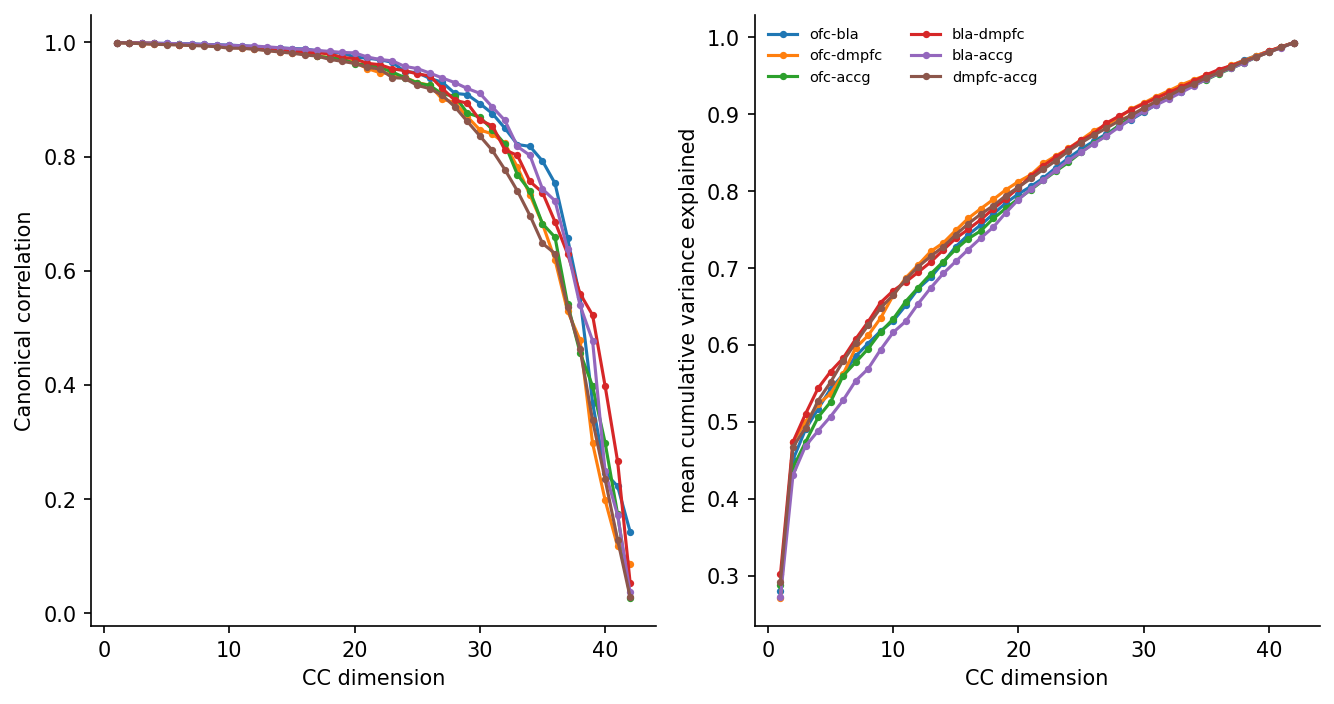

In [4]:
pooled_cca_df, pooled_cca_payloads = compute_pairwise_regional_pc_cca(
    targets.pcs_by_region,
    region_order=targets.region_order,
    max_components=42,
)
pooled_cca_df.insert(0, "fixation_type", "pooled")
display(pooled_cca_df.head(12))
fig, axes = plot_pairwise_cca_variance(pooled_cca_df, max_dimensions=42)
fig.suptitle("Pooled fixation types", y=1.03)
display_figure(fig)

cca_df = pooled_cca_df
cca_payloads = pooled_cca_payloads

In [5]:
summary_cols = [
    "fixation_type",
    "region_a",
    "region_b",
    "cca_dimension",
    "canonical_correlation",
    "mean_cumulative_variance_explained",
]
display(
    cca_df.loc[cca_df["cca_dimension"].isin([1, 5, 10, 20, 42]), summary_cols]
    .sort_values(["fixation_type", "region_a", "region_b", "cca_dimension"])
    .reset_index(drop=True)
)

,region_a,region_b,cca_dimension,canonical_correlation,mean_cumulative_variance_explained
0,bla,accg,1,0.999697,0.272574
1,bla,accg,5,0.998134,0.507207
2,bla,accg,10,0.994860,0.616584
3,bla,accg,20,0.981668,0.789227
4,bla,accg,42,0.036775,0.993424
5,bla,dmpfc,1,0.999703,0.302022
6,bla,dmpfc,5,0.997419,0.565570
7,bla,dmpfc,10,0.992481,0.670747
8,bla,dmpfc,20,0.971536,0.804550
9,bla,dmpfc,42,0.053770,0.993420


## 4b. Fixation-Type-Specific Regional CCA

The pooled CCA above concatenates all three fixation types across the observation axis. This section repeats the same region-pair CCA separately for each fixation type, using time bins as observations within that condition.

In [ ]:
condition_cca_tables = []
condition_cca_payloads = {}
for cond_idx, condition in enumerate(targets.condition_order):
    condition_pcs = {
        region: targets.pcs_by_region[region][cond_idx : cond_idx + 1]
        for region in targets.region_order
    }
    cond_df, cond_payload = compute_pairwise_regional_pc_cca(
        condition_pcs,
        region_order=targets.region_order,
        max_components=42,
    )
    cond_df.insert(0, "fixation_type", condition)
    condition_cca_tables.append(cond_df)
    condition_cca_payloads[condition] = cond_payload

condition_cca_df = pd.concat(condition_cca_tables, ignore_index=True)
display(condition_cca_df.head(12))
for condition, sub in condition_cca_df.groupby("fixation_type", sort=False):
    fig, axes = plot_pairwise_cca_variance(sub, max_dimensions=42)
    fig.suptitle(condition, y=1.03)
    display_figure(fig)

all_cca_df = pd.concat([pooled_cca_df, condition_cca_df], ignore_index=True)


In [ ]:
display(
    all_cca_df.loc[all_cca_df["cca_dimension"].isin([1, 5, 10, 20, 42]), summary_cols]
    .sort_values(["fixation_type", "region_a", "region_b", "cca_dimension"])
    .reset_index(drop=True)
)

## 5. Train or Load the Three Connectivity Models

In [6]:
connectivity_variants = {
    "full": "full",
    "within_region": "within_region",
    "cross_region_with_self_diagonal": "cross_region_with_self_diagonal",
}
run_mode = "train"  # use "train" to refit; use "load" to read existing scratch runs
overwrite = False


def load_or_train_connectivity_model(label, connectivity):
    settings = replace(base_settings, recurrent_connectivity=connectivity)
    scratch_id = f"cca_42pc_tanh_h50_{label}"
    run_root = Path(settings.output_subdir)
    if run_mode == "train":
        result = train_fixation_mrnn_scratch(settings, scratch_id=scratch_id, overwrite=overwrite)
        replay = replay_fixation_mrnn_run(result["run_dir"], device=settings.device)
        return {"label": label, "settings": settings, "result": result, "replay": replay}

    from dal_monte_2022_analysis.ephys.modeling import resolve_fixation_mrnn_output_root
    run_dir = resolve_fixation_mrnn_output_root(settings) / "scratch" / scratch_id
    checkpoint = run_dir / "checkpoint_final.pth"
    if not checkpoint.exists():
        print(f"Missing checkpoint for {label}: {checkpoint}")
        return {"label": label, "settings": settings, "result": None, "replay": None}
    replay = replay_fixation_mrnn_run(run_dir, device=settings.device)
    history = pd.read_csv(run_dir / "history.csv")
    return {"label": label, "settings": settings, "result": {"run_dir": run_dir, "history": history}, "replay": replay}

fits = [
    load_or_train_connectivity_model(label, connectivity)
    for label, connectivity in connectivity_variants.items()
]
[(fit["label"], None if fit["replay"] is None else str(fit["result"]["run_dir"])) for fit in fits]

region_pcs seed=211382628:   0%|          | 0/50000 [00:00<?, ?iter/s]

region_pcs seed=211382628:   0%|          | 0/50000 [00:00<?, ?iter/s]

region_pcs seed=211382628:   0%|          | 0/50000 [00:00<?, ?iter/s]

[('full',
  '/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/cca_42pc_tanh_h50_full'),
 ('within_region',
  '/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/cca_42pc_tanh_h50_within_region'),
 ('cross_region_with_self_diagonal',
  '/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/cca_42pc_tanh_h50_cross_region_with_self_diagonal')]

## 6. Loss Curves

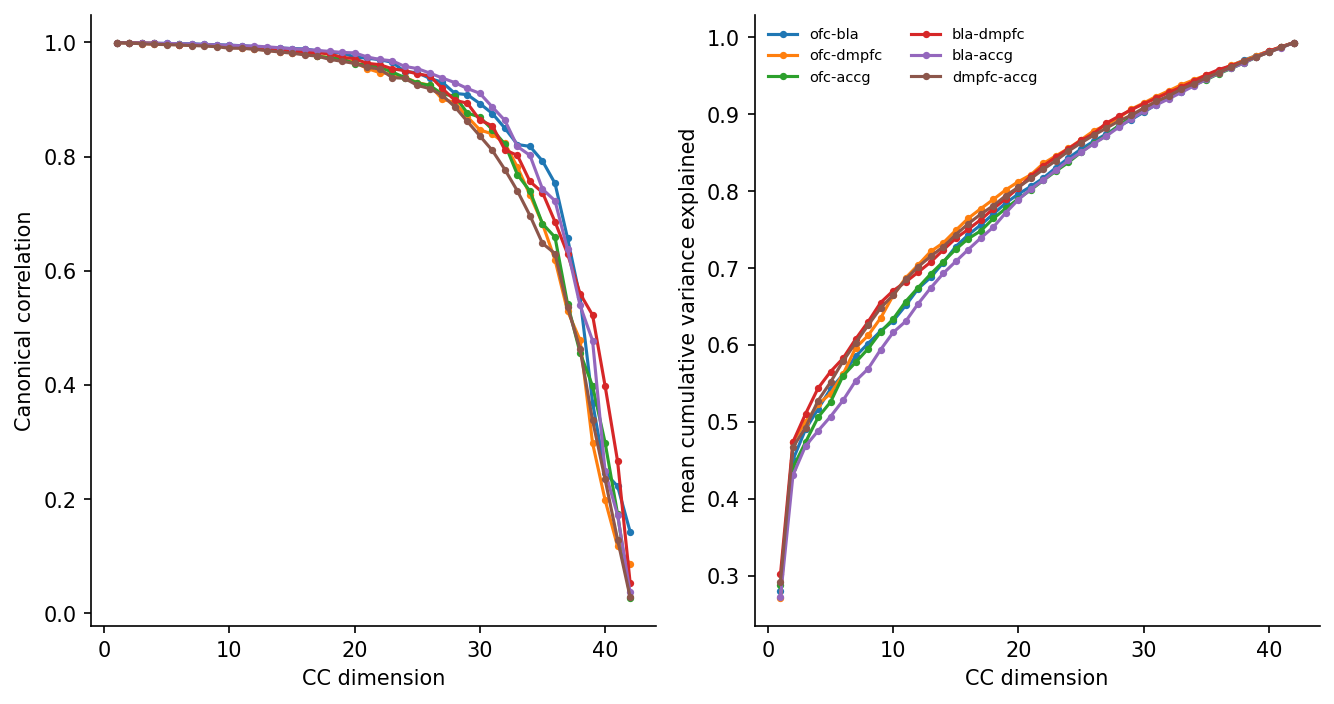

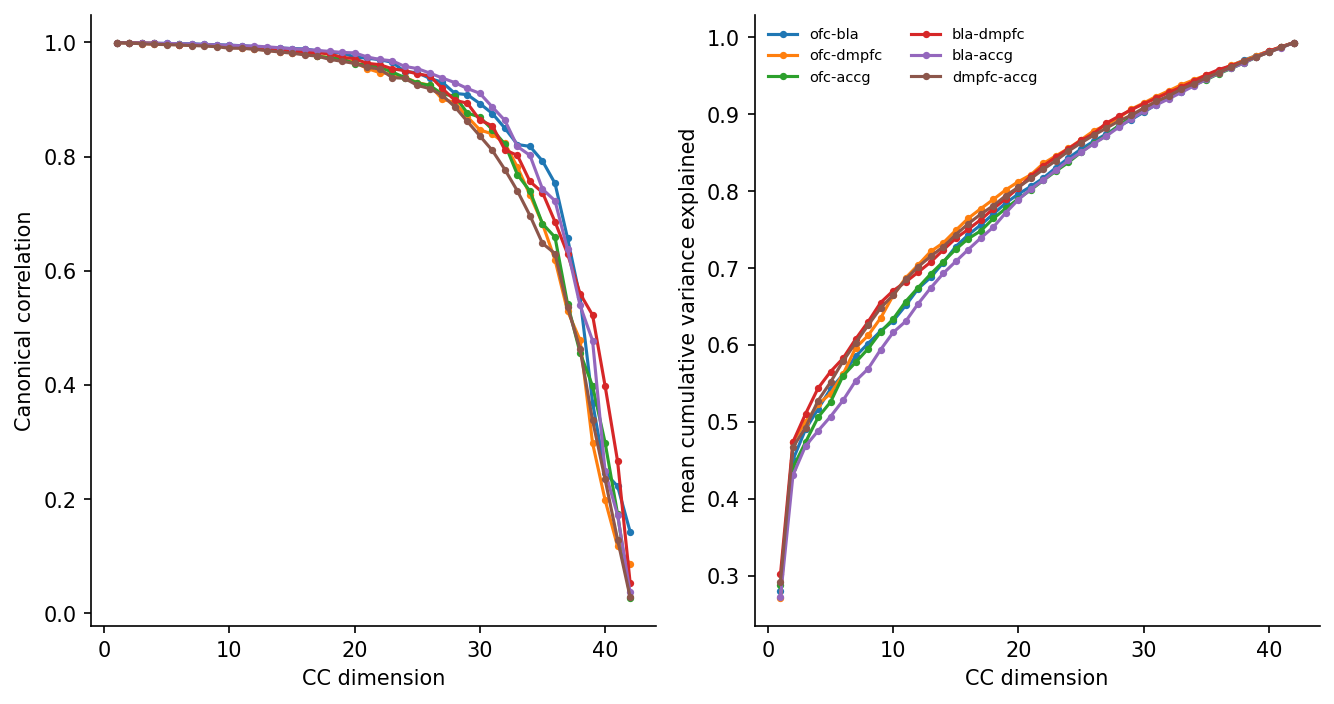

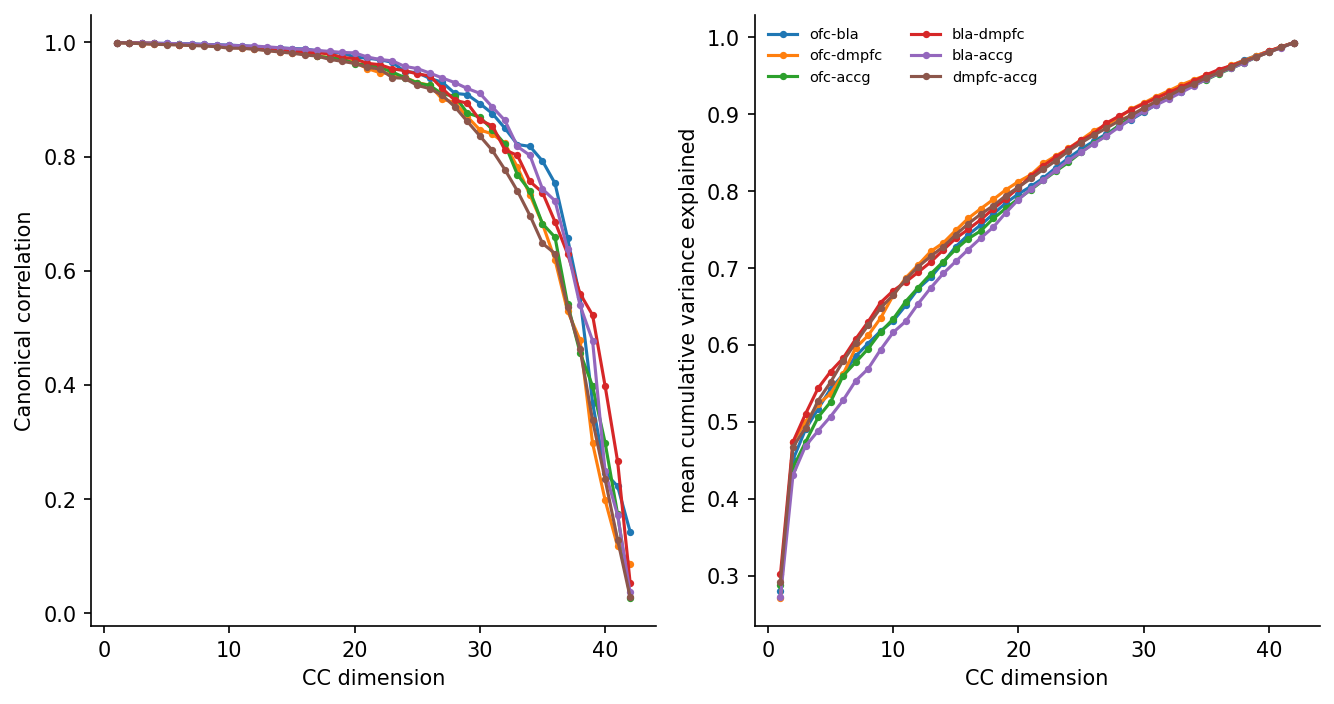

In [7]:
def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(8.0, 4.0), dpi=130)
    columns = [
        ("loss", "total"),
        ("reconstruction_loss", "PC pointwise"),
        ("temporal_derivative_loss", "PC derivative"),
        ("temporal_curvature_loss", "PC curvature"),
        ("correlation_loss", "PC correlation"),
        ("variance_loss", "PC variance"),
        ("fr_reconstruction_loss", "FR pointwise"),
        ("fr_temporal_derivative_loss", "FR derivative"),
        ("fr_temporal_curvature_loss", "FR curvature"),
    ]
    for column, label in columns:
        if column in history:
            ax.plot(history["iteration"], history[column], label=label, linewidth=1.2)
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.tight_layout()
    return fig, ax

for fit in fits:
    if fit["result"] is None:
        continue
    history = fit["result"]["history"]
    fig, axes = plot_loss(history, fit["label"])
    display_figure(fig)

## 7. PC Reconstruction Quality

In [8]:
pc_metric_tables = []
for fit in fits:
    if fit["replay"] is None:
        continue
    metrics = reconstruction_accuracy(fit["replay"])
    metrics.insert(0, "model", fit["label"])
    pc_metric_tables.append(metrics)

pc_metrics = pd.concat(pc_metric_tables, ignore_index=True) if pc_metric_tables else pd.DataFrame()
display(pc_metrics)
if not pc_metrics.empty:
    display(
        pc_metrics.groupby(["model", "region"], sort=False)[["r2", "correlation", "mse", "mae"]]
        .mean(numeric_only=True)
        .reset_index()
    )

,model,region,condition,mse,mae,r2,correlation
0,full,ofc,face_interactive,0.000036,0.004536,0.995877,0.997961
1,full,ofc,face_non_interactive,0.000047,0.005249,0.996295,0.998146
2,full,ofc,object,0.000049,0.005274,0.997378,0.998688
3,full,bla,face_interactive,0.000042,0.004778,0.996996,0.998515
4,full,bla,face_non_interactive,0.000056,0.005718,0.998002,0.999001
5,full,bla,object,0.000052,0.005597,0.998218,0.999109
6,full,dmpfc,face_interactive,0.000041,0.004748,0.990281,0.995189
7,full,dmpfc,face_non_interactive,0.000041,0.004826,0.996405,0.998201
8,full,dmpfc,object,0.000036,0.004447,0.995978,0.997988
9,full,accg,face_interactive,0.000028,0.003910,0.989000,0.994587


,model,region,r2,correlation,mse,mae
0,full,ofc,0.996517,0.998265,0.000044,0.005020
1,full,bla,0.997739,0.998875,0.000050,0.005364
2,full,dmpfc,0.994221,0.997126,0.000039,0.004674
3,full,accg,0.992885,0.996469,0.000032,0.004206
4,within_region,ofc,0.975936,0.988084,0.000298,0.012904
5,within_region,bla,0.983683,0.991871,0.000347,0.014379
6,within_region,dmpfc,0.952296,0.976651,0.000325,0.013687
7,within_region,accg,0.922724,0.963260,0.000364,0.014041
8,cross_region_with_self_diagonal,ofc,0.994264,0.997159,0.000069,0.006232
9,cross_region_with_self_diagonal,bla,0.997022,0.998519,0.000066,0.006106


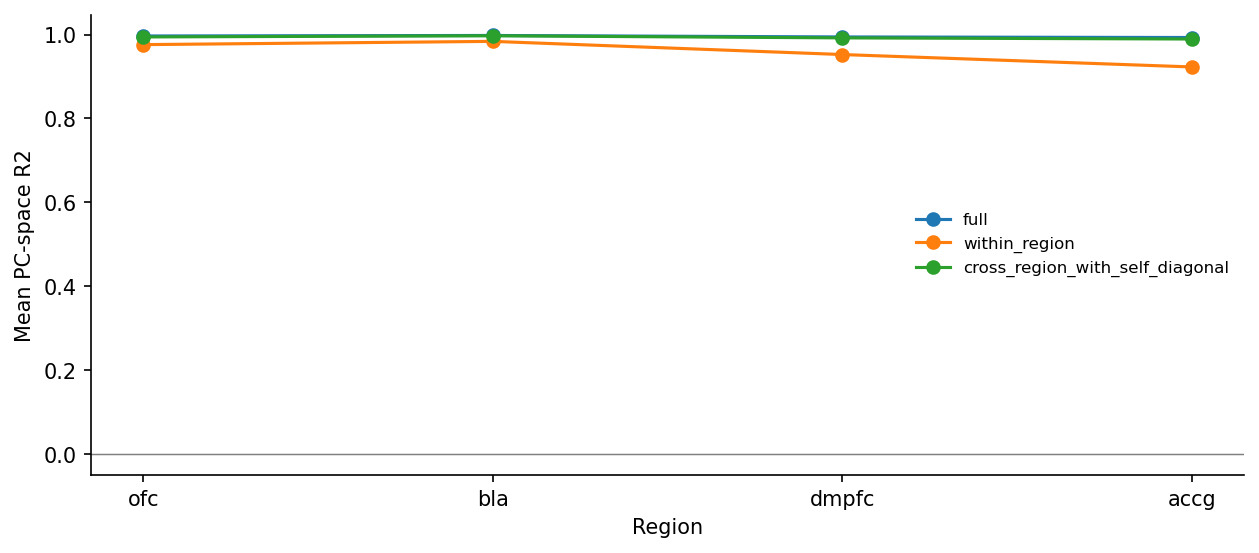

In [9]:
if not pc_metrics.empty:
    fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=130)
    summary = pc_metrics.groupby(["model", "region"], sort=False)["r2"].mean().reset_index()
    for model, sub in summary.groupby("model", sort=False):
        ax.plot(sub["region"], sub["r2"], marker="o", label=model)
    ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_ylabel("Mean PC-space R2")
    ax.set_xlabel("Region")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    display_figure(fig)

## 8. Firing-Rate Reconstruction Quality From PC Backprojection

In [10]:
fr_metric_tables = []
variance_tables = []
for fit in fits:
    if fit["replay"] is None:
        continue
    fr_metrics = pc_reconstructed_firing_rate_accuracy(fit["replay"])
    fr_metrics.insert(0, "model", fit["label"])
    fr_metric_tables.append(fr_metrics)
    var_metrics = variance_comparison(fit["replay"])
    var_metrics.insert(0, "model", fit["label"])
    variance_tables.append(var_metrics)

fr_metrics = pd.concat(fr_metric_tables, ignore_index=True) if fr_metric_tables else pd.DataFrame()
variance_metrics = pd.concat(variance_tables, ignore_index=True) if variance_tables else pd.DataFrame()
display(fr_metrics)
if not fr_metrics.empty:
    display(
        fr_metrics.groupby(["model", "region"], sort=False)[["r2", "correlation", "mse", "mae"]]
        .mean(numeric_only=True)
        .reset_index()
    )
display(variance_metrics)

,model,region,condition,mse,mae,r2,correlation
0,full,ofc,face_interactive,0.000006,0.001709,0.999933,0.999966
1,full,ofc,face_non_interactive,0.000008,0.001965,0.999906,0.999953
2,full,ofc,object,0.000008,0.001982,0.999902,0.999951
3,full,bla,face_interactive,0.000003,0.001227,0.999958,0.999979
4,full,bla,face_non_interactive,0.000004,0.001421,0.999940,0.999970
5,full,bla,object,0.000004,0.001364,0.999949,0.999974
6,full,dmpfc,face_interactive,0.000009,0.002138,0.999838,0.999919
7,full,dmpfc,face_non_interactive,0.000009,0.002108,0.999843,0.999921
8,full,dmpfc,object,0.000008,0.001966,0.999852,0.999926
9,full,accg,face_interactive,0.000005,0.001611,0.999849,0.999925


,model,region,r2,correlation,mse,mae
0,full,ofc,0.999913,0.999957,0.000008,0.001885
1,full,bla,0.999949,0.999974,0.000004,0.001337
2,full,dmpfc,0.999844,0.999922,0.000009,0.002071
3,full,accg,0.999821,0.999911,0.000006,0.001700
4,within_region,ofc,0.999412,0.999706,0.000052,0.005020
5,within_region,bla,0.999645,0.999823,0.000027,0.003500
6,within_region,dmpfc,0.998702,0.999352,0.000073,0.006072
7,within_region,accg,0.997951,0.998979,0.000065,0.005836
8,cross_region_with_self_diagonal,ofc,0.999863,0.999932,0.000012,0.002401
9,cross_region_with_self_diagonal,bla,0.999932,0.999966,0.000005,0.001531


,model,region,observed_variance,reconstructed_variance,reconstructed_to_observed_ratio
0,full,ofc,0.013428,0.013421,0.999497
1,full,bla,0.024063,0.024064,1.000058
2,full,dmpfc,0.008286,0.008289,1.000294
3,full,accg,0.005290,0.005290,1.000025
4,within_region,ofc,0.013428,0.013408,0.998509
5,within_region,bla,0.024063,0.024018,0.998128
6,within_region,dmpfc,0.008286,0.008280,0.999265
7,within_region,accg,0.005290,0.005277,0.997534
8,cross_region_with_self_diagonal,ofc,0.013428,0.013434,1.000506
9,cross_region_with_self_diagonal,bla,0.024063,0.024050,0.999451


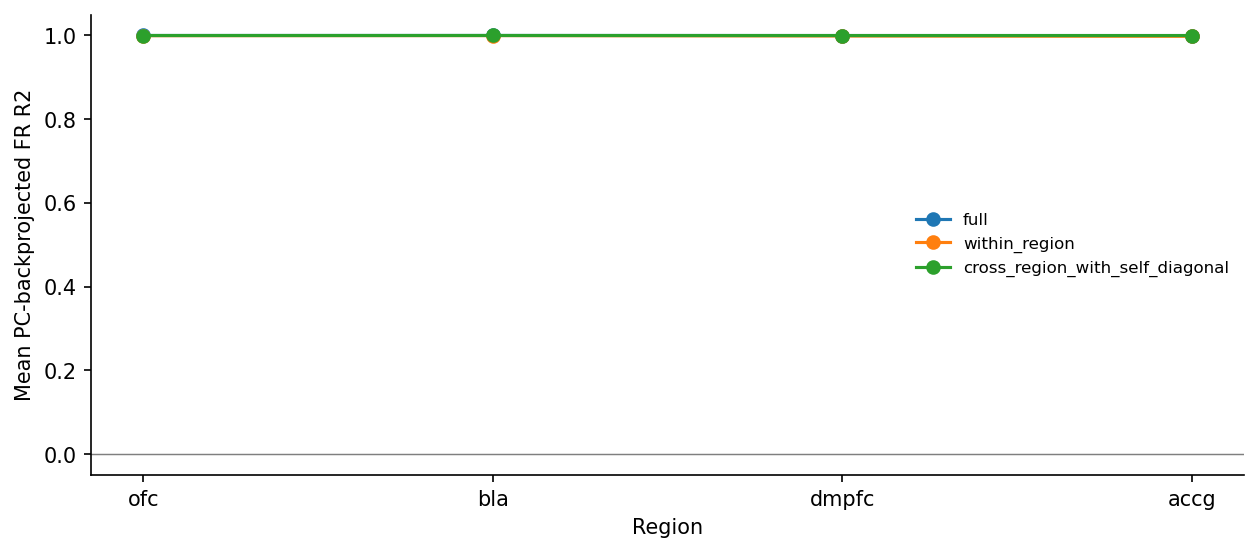

In [11]:
if not fr_metrics.empty:
    fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=130)
    summary = fr_metrics.groupby(["model", "region"], sort=False)["r2"].mean().reset_index()
    for model, sub in summary.groupby("model", sort=False):
        ax.plot(sub["region"], sub["r2"], marker="o", label=model)
    ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_ylabel("Mean PC-backprojected FR R2")
    ax.set_xlabel("Region")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    display_figure(fig)

## 9. Visual Reconstruction Overlays


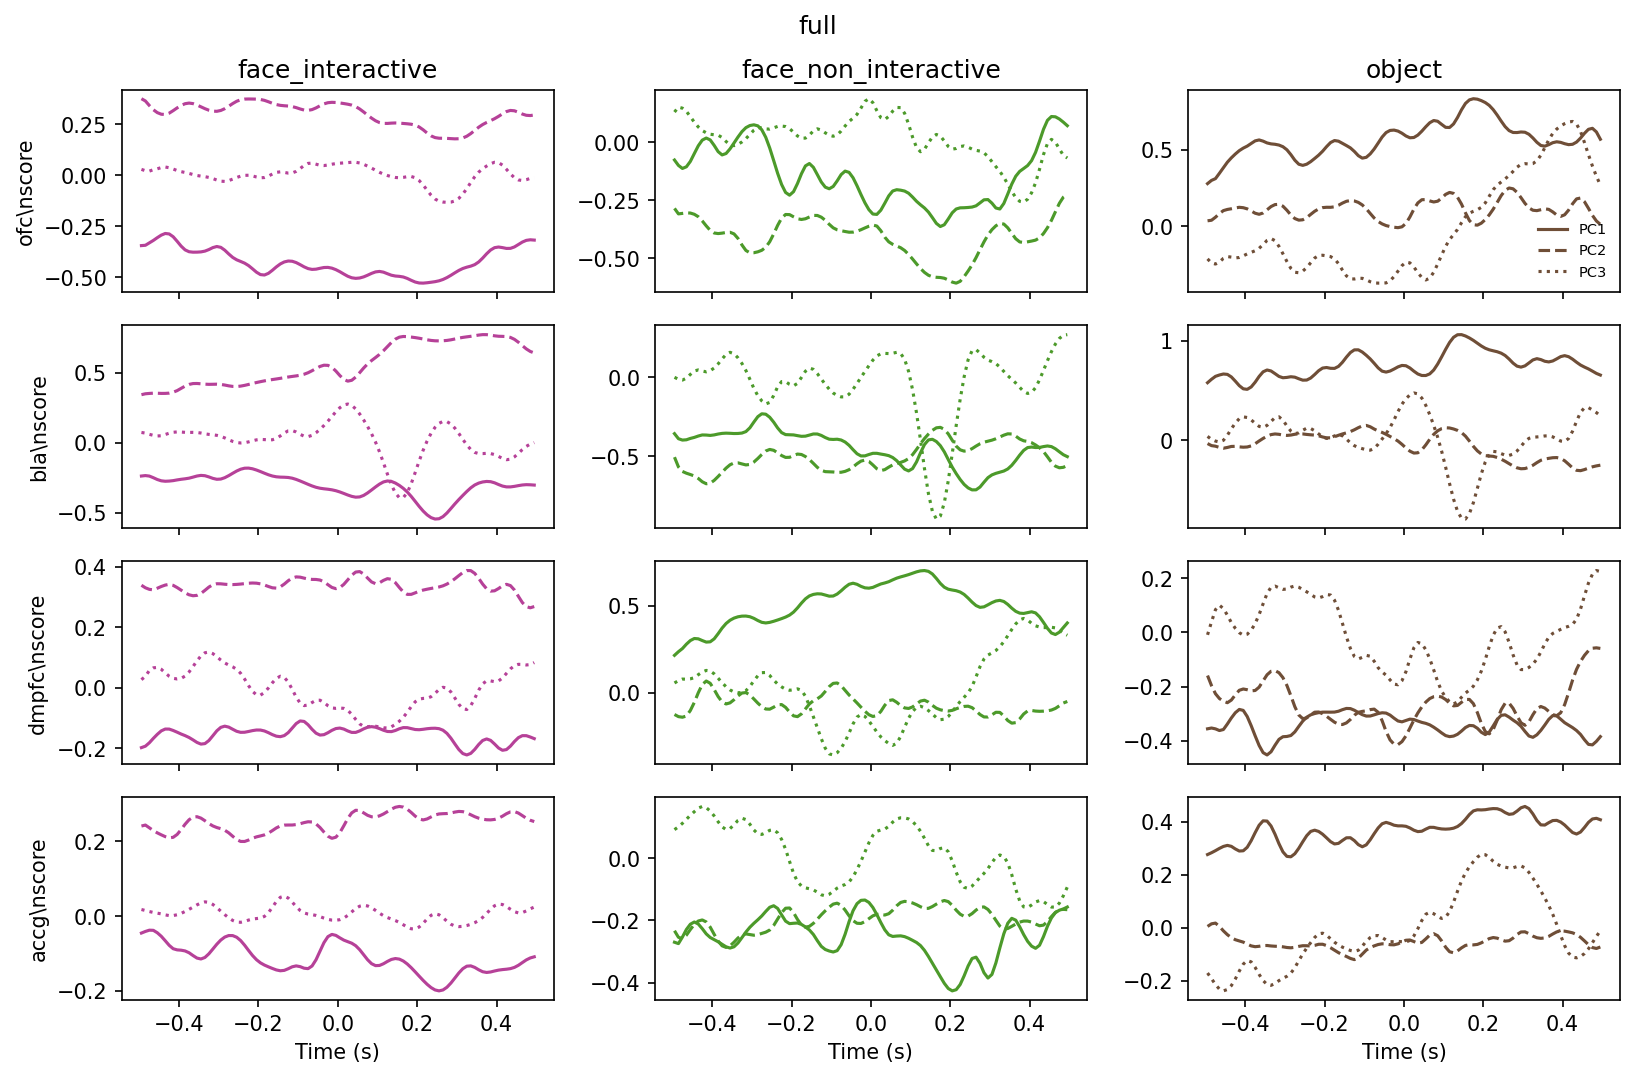

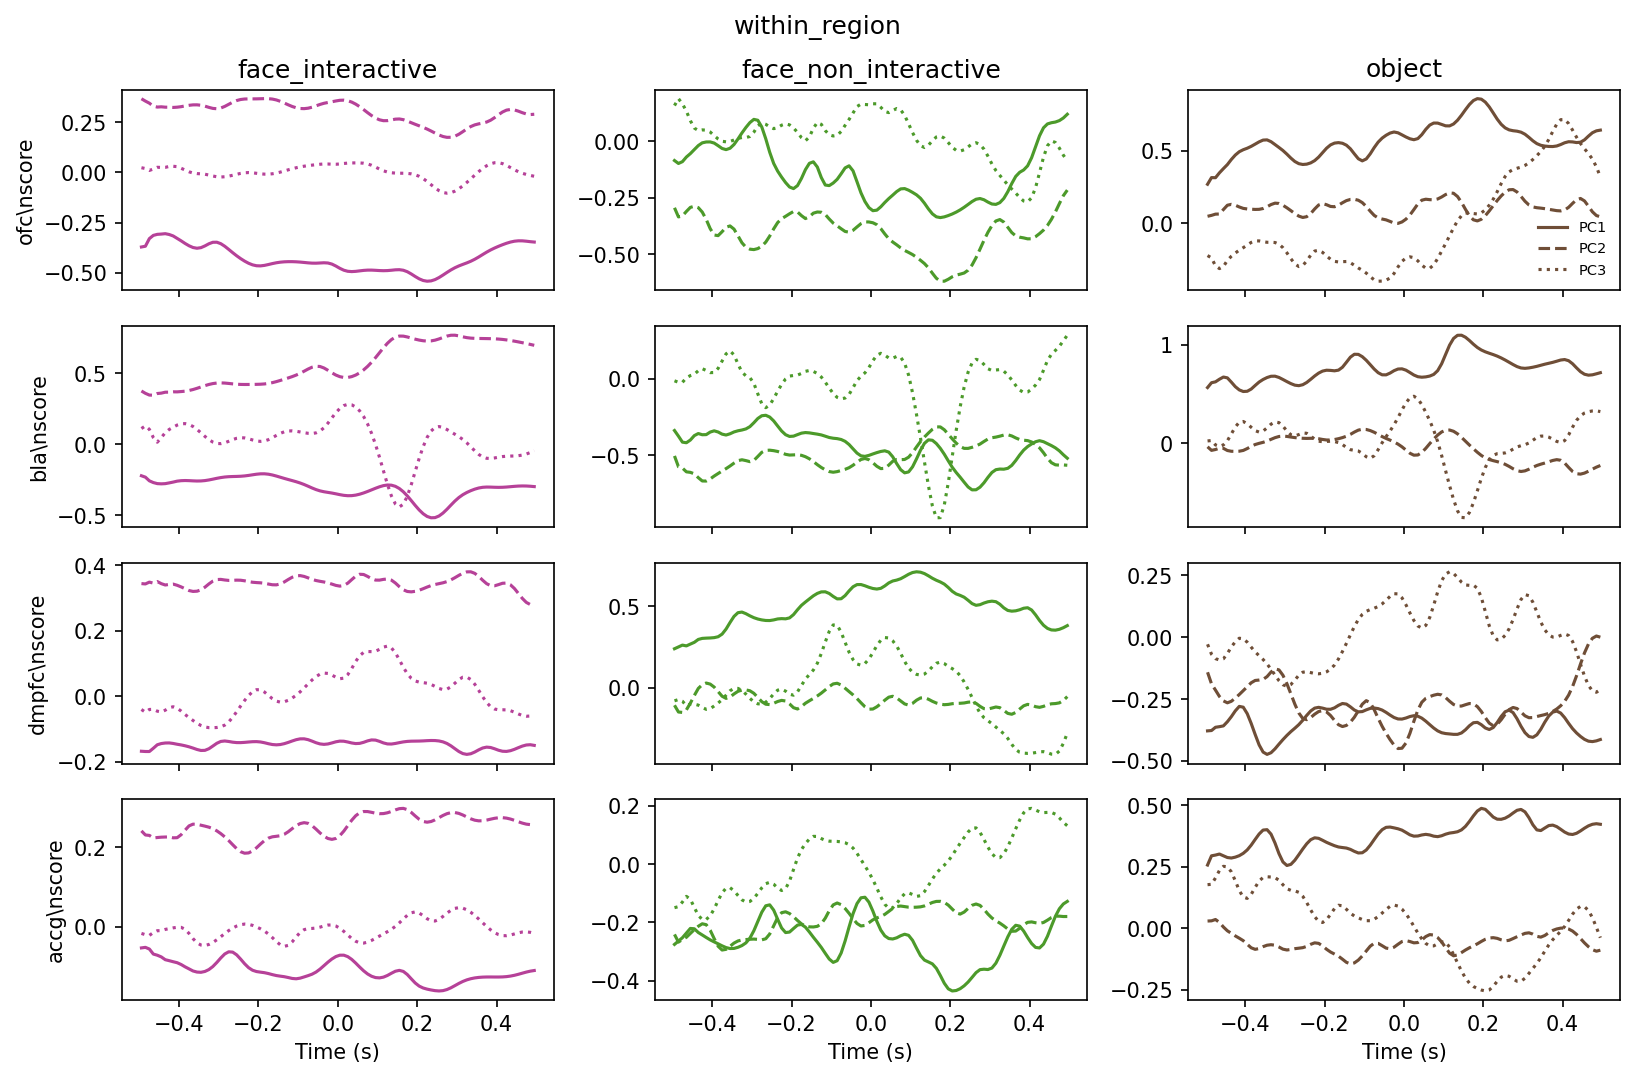

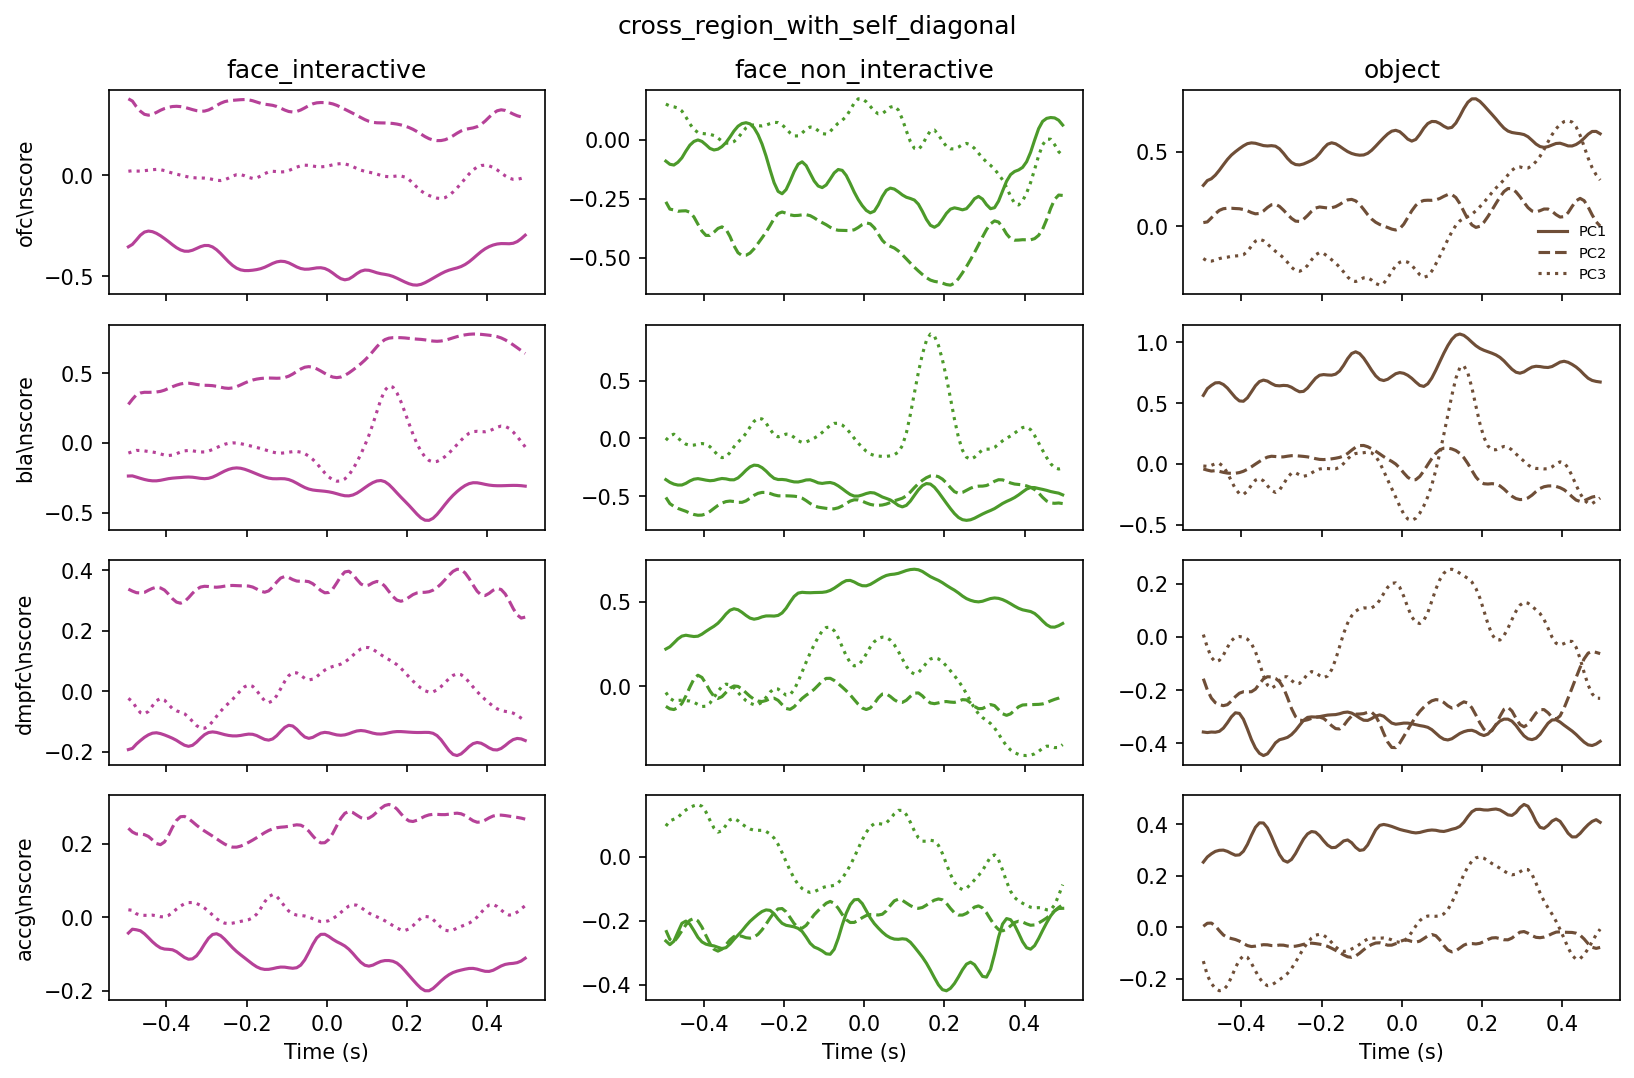

In [12]:
def _as_numpy_tensor(value):
    if hasattr(value, "detach"):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def plot_pc_reconstruction_overlay(replay, *, model_label, max_pcs=4):
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    timeline = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    n_cols = min(int(max_pcs), min(np.asarray(replay["checkpoint"]["target_by_region"][regions[0]]).shape[-1], 4))
    fig, axes = plt.subplots(
        len(regions),
        n_cols,
        figsize=(3.2 * n_cols, 2.2 * len(regions)),
        dpi=130,
        squeeze=False,
        sharex=True,
    )
    for row, region in enumerate(regions):
        target = np.asarray(replay["checkpoint"]["target_by_region"][region], dtype=float)
        pred = _as_numpy_tensor(replay["output_by_region"][region]).astype(float)
        for pc_idx in range(n_cols):
            ax = axes[row, pc_idx]
            for cond_idx, condition in enumerate(conditions):
                color = plt.get_cmap("tab10")(cond_idx)
                ax.plot(timeline, target[cond_idx, :, pc_idx], color=color, linewidth=1.4, label=f"{condition} target")
                ax.plot(timeline, pred[cond_idx, :, pc_idx], color=color, linewidth=1.2, linestyle="--", label=f"{condition} fit")
            ax.axvline(0.0, color="black", linewidth=0.6, alpha=0.45)
            if row == 0:
                ax.set_title(f"PC{pc_idx + 1}")
            if pc_idx == 0:
                ax.set_ylabel(region)
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
            ax.spines[["top", "right"]].set_visible(False)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{model_label}: PC target vs fit", y=1.08)
    fig.tight_layout()
    return fig, axes


def plot_fr_reconstruction_overlay(replay, *, model_label, max_units=4):
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    timeline = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    target_by_region = replay["checkpoint"].get("pc_reconstructed_raw_by_region")
    if target_by_region is None:
        target_by_region = replay["checkpoint"]["target_by_region"]
    predicted_by_region = backproject_replay_outputs_to_firing_rates(replay)
    n_cols = min(int(max_units), min(np.asarray(target_by_region[region]).shape[-1] for region in regions), 4)
    fig, axes = plt.subplots(
        len(regions),
        n_cols,
        figsize=(3.2 * n_cols, 2.2 * len(regions)),
        dpi=130,
        squeeze=False,
        sharex=True,
    )
    for row, region in enumerate(regions):
        target = np.asarray(target_by_region[region], dtype=float)
        pred = np.asarray(predicted_by_region[region], dtype=float)
        for unit_idx in range(n_cols):
            ax = axes[row, unit_idx]
            for cond_idx, condition in enumerate(conditions):
                color = plt.get_cmap("tab10")(cond_idx)
                ax.plot(timeline, target[cond_idx, :, unit_idx], color=color, linewidth=1.4, label=f"{condition} target")
                ax.plot(timeline, pred[cond_idx, :, unit_idx], color=color, linewidth=1.2, linestyle="--", label=f"{condition} fit")
            ax.axvline(0.0, color="black", linewidth=0.6, alpha=0.45)
            if row == 0:
                ax.set_title(f"FR trace {unit_idx + 1}")
            if unit_idx == 0:
                ax.set_ylabel(region)
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
            ax.spines[["top", "right"]].set_visible(False)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{model_label}: PC-backprojected firing-rate target vs fit", y=1.08)
    fig.tight_layout()
    return fig, axes


for fit in fits:
    if fit["replay"] is None:
        continue
    fig, axes = plot_pc_reconstruction_overlay(fit["replay"], model_label=fit["label"], max_pcs=4)
    display_figure(fig)
    fig, axes = plot_fr_reconstruction_overlay(fit["replay"], model_label=fit["label"], max_units=4)
    display_figure(fig)
